In [1]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import warnings
import scipy.ndimage as ndimage
from scipy import stats

sns.set(style="ticks", palette="Set2", context="notebook", rc={'axes.formatter.limits': (-3, 3)})
warnings.filterwarnings(action='ignore')
from sklearn.linear_model import LinearRegression
import pandas as pd

import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from scipy.sparse import csr_matrix
import matplotlib.colors as mcolors

import gzip
from pathlib import Path
import matplotlib.ticker as mticker

In [2]:
# some helper functions for plots:


def _p_plain(p, sig=3):
    if p <= 0:
        return "0"
    decimals = max(0, sig - 1 - int(np.floor(np.log10(abs(p)))))
    return f"{p:.{decimals}f}"

def _p_label(p):
    return f"p={_p_plain(p)}"

def _annotate_pstars(ax, x_positions, slopes, ses, pvals, fontsize=3):
    y0, y1 = ax.get_ylim()
    pad = 0.03 * (y1 - y0)
    for x, s, se, p in zip(x_positions, slopes, ses, pvals):
        y = max(s + se, 0) + pad
        ax.text(x, y, _p_label(p), ha="center", va="bottom", fontsize=fontsize)
    ax.margins(y=0.22) 


In [3]:
conversion_df = pl.read_csv("external_data/metalloproteome_exp_conversion.csv")

end_values = conversion_df["End"].unique().to_list()
index_values = conversion_df["Index"].unique().to_list()

end_dict = {end: i for i, end in enumerate(end_values)}
index_dict = {index: i for i, index in enumerate(index_values)}

conversion_df = conversion_df.with_columns(x=pl.col("End").replace(end_dict))
conversion_df = conversion_df.with_columns(y=pl.col("Index").replace(index_dict))

conversion_df = conversion_df.drop(["Start", "End", "Index"])
gene_df = pl.read_csv("data/accession_gene_dict.csv")
gene_dict = dict(zip(gene_df["Accession Number"], gene_df["Gene Name"]))
prot_df_raw = pl.read_csv('external_data/metalloproteome_proteins.csv')

prot_df = prot_df_raw.drop(["#", "Visible?", "Starred?", "Molecular Weight", "Taxonomy"])
prot_df = prot_df.with_columns(Gene=pl.col("Accession Number").replace(gene_dict))
prot_df = prot_df.drop(["Identified Proteins (1235)", "Accession Number"])
prot_df = prot_df.unique(subset=["Gene"], maintain_order=True)

prot_exp_names = list(prot_df.columns)[:-1]
gene_names = prot_df["Gene"].to_list()

prot_df = prot_df.drop(["Gene"]).transpose()
prot_df.columns = gene_names
prot_df = prot_df.with_columns(pl.Series(name="Experiment", values=prot_exp_names))
prot_df = prot_df.join(conversion_df, on="Experiment")
metal_df = pl.read_csv('external_data/metalloproteome_metals.csv')
metal_df = metal_df.drop([col for col in metal_df.columns if col.startswith("_dupli")])
metal_df = metal_df.drop([col for col in metal_df.columns if len(col) < 2])

metals = metal_df.columns[1:]

metal_join_df = metal_df.join(conversion_df, on="Experiment")

x_min = 3
y_min = 1
x_max = 15
y_max = 26

metal_join_df = metal_join_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))
prot_df = prot_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))
# Zero out isolated protein signals with no neighboring support
footprint = np.array([[1,1,1],
                      [1,0,1],
                      [1,1,1]])

for protein in gene_names:
    prot_pivot = prot_df.pivot(values=protein, index="x", on="y").to_numpy()[:, 1:]

    prot_mask = prot_pivot > 0

    f = lambda x: x.sum()

    results = ndimage.generic_filter(prot_mask, f, footprint=footprint, mode="constant", cval=0)

    prot_pivot_true_mask = prot_mask & results

    if prot_pivot_true_mask.sum() > 0:
        prot_pivot[~prot_pivot_true_mask] = 0

    prot_df = prot_df.with_columns(pl.Series(name=protein, values=prot_pivot.flatten()))
# Replace extreme outlier wells with per-metal median values
problem_wells = [[11, 7], [12, 7], [9, 21]]

for metal in metals:
    metal_pivot = metal_join_df.pivot(values=metal, index="x", on="y").to_numpy()[:, 1:]

    for well in problem_wells:
        metal_pivot[well[0], well[1]] = np.median(metal_pivot)

    metal_join_df = metal_join_df.with_columns(pl.Series(name=metal, values=metal_pivot.flatten()))
gene = "YggX"

# Match element colors to final_paper_validation.ipynb (Set2, order: Fe Zn Mn Cu Mo Ni Co Cr)
_set2 = sns.color_palette("Set2")
element_palette = {
    "Fe": _set2[0], "Zn": _set2[1], "Mn": _set2[2], "Cu": _set2[3],
    "Mo": _set2[4], "Ni": _set2[5], "Co": _set2[6], "Cr": _set2[7],
}
isotope_display_dict = {
    "56Fe": "Fe", "66Zn": "Zn", "55Mn": "Mn", "63Cu": "Cu",
    "60Ni": "Ni", "59Co": "Co", "52Cr": "Cr",
}
element_order = ["Fe", "Zn", "Mn", "Co", "Cu", "Ni", "Cr"]


def capitalize_first_and_last(s):
    if len(s) == 0:
        return s
    elif len(s) == 1:
        return s.upper()
    else:
        return s[0].upper() + s[1:-1] + s[-1].upper()

prot_df.columns = [capitalize_first_and_last(col) if col not in ['x', 'y', 'Experiment'] else col for col in prot_df.columns]


YggX_subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

YggX_subset = metal_join_df.select(["x", "y", "60Ni", "59Co", "63Cu","52Cr", "56Fe", "55Mn", "66Zn"]).join(YggX_subset, on=["x", "y"], how="inner")

YggX_subset = YggX_subset.with_columns(pl.col(["60Ni", "59Co", "63Cu", "52Cr", "56Fe","55Mn", "66Zn", gene]))

YggX_subset = YggX_subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

YggX_subset = YggX_subset.with_columns(pl.col("Element").replace(isotope_display_dict))

In [4]:
metal = "60Ni"
metal1 = "63Cu"
metal2 = "52Cr"
metal3 = "59Co"

genes = prot_df.unpivot(index=["x", "y", "Experiment",], variable_name="Gene", value_name="Spectral count").unique(["Gene"]).select(["Gene"]).to_numpy().flatten().tolist()

values = []

for g in genes:
    gene_sum = prot_df.select(pl.col(g)).sum()[0, 0]
    
    if gene_sum < 200:
        obj = 0.0
    else:
        obj = metal_join_df.select(["x", "y", metal]).join(prot_df.select(["x", "y", g]), on=["x", "y"], how="inner").select([metal, g]).with_columns((pl.col(g) * pl.col(metal) / gene_sum).alias("Obj")).sum().select("Obj")[0, 0]
    
    values.append(obj)
    
out = pl.DataFrame({"Gene": genes, "Objective": values}).sort("Objective", descending=True).filter(pl.col("Gene").str.starts_with("Y"))
print(out.shape)

(186, 2)


In [5]:
# weighted average of specific metal count attributed to genes, with minimum protein count to filter out noise
def compute_objectives(metal, min_counts=200):
    genes = [c for c in prot_df.columns if c not in ("x", "y", "Experiment")]
    values = []
    for gene in genes:
        gene_sum = prot_df.select(pl.col(gene)).sum()[0, 0]
        if gene_sum < min_counts:
            values.append(0.0)
            continue
        obj = (
            metal_join_df.select(["x", "y", metal])
            .join(prot_df.select(["x", "y", gene]), on=["x", "y"], how="inner")
            .with_columns((pl.col(gene) * pl.col(metal) / gene_sum).alias("Obj"))
            .select("Obj").sum()[0, 0]
        )
        values.append(obj)
    return pl.DataFrame({"Gene": genes, "Objective": values})

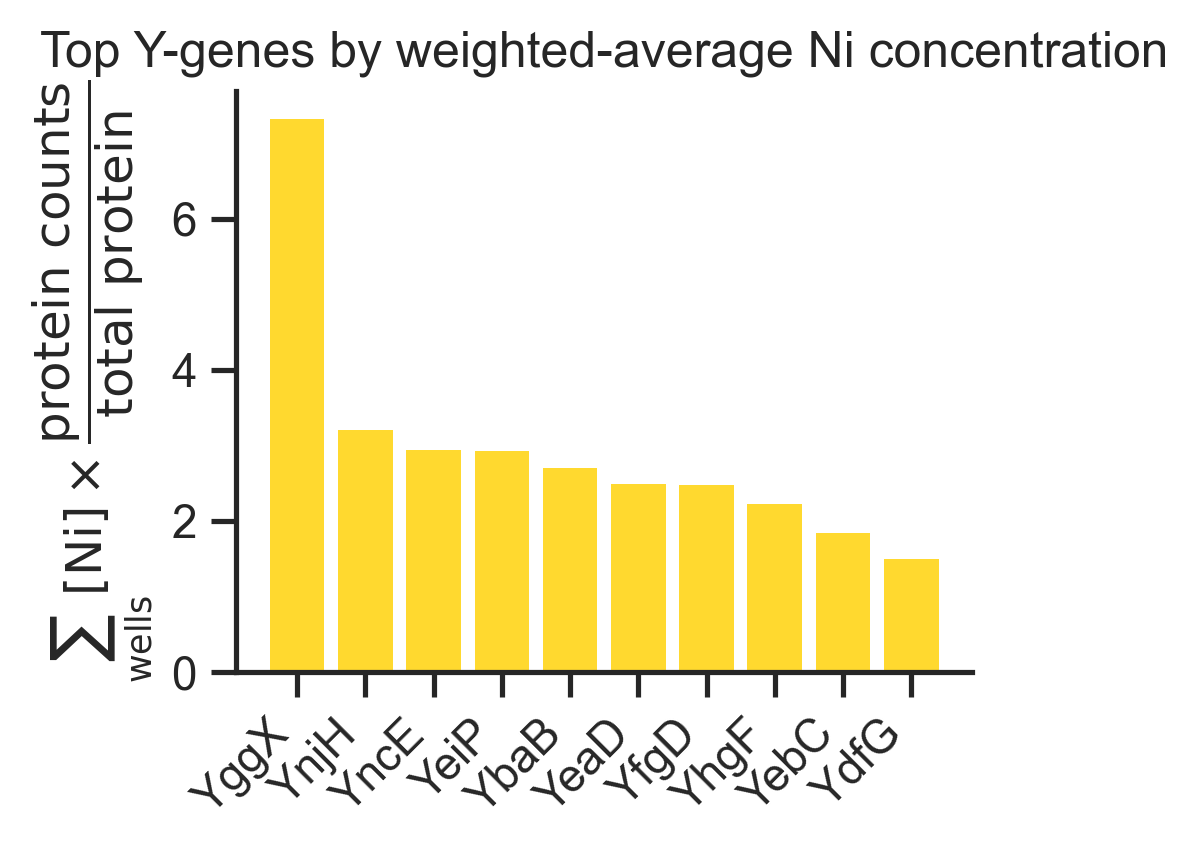

In [6]:
#ranked bar plot based on weighted average for Y-genes for Nickle
metal = "60Ni"
metal1 = "63Cu"
metal2 = "52Cr"
metal3 = "59Co"

elem = isotope_display_dict[metal] 
top = (
    compute_objectives(metal)
    .filter(pl.col("Gene").str.starts_with("Y"))
    .sort("Objective", descending=True)
    .head(10)
)

fig, ax = plt.subplots(figsize=(3.5, 3.0))
ax.bar(
    top["Gene"].to_list(),
    top["Objective"].to_list(),
    color=element_palette[elem],
    edgecolor="none",
)

ax.set_ylabel(
    rf"$\sum_{{\mathrm{{wells}}}} [\mathrm{{{elem}}}]\times"
    rf"\dfrac{{\mathrm{{protein\ counts}}}}{{\mathrm{{total\ protein}}}}$"
)
ax.set_title(f"Top Y-genes by weighted-average {elem} concentration")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig(f'figures/yggX_weighted_{metal}_Average_bar.svg',
            format="svg", bbox_inches="tight")
plt.savefig(f'figures/yggX_weighted_{metal}_Average_bar.png',
            format="png", bbox_inches="tight")
plt.show()

In [7]:
def read_names(file_path):
    return np.genfromtxt(file_path, dtype=str, delimiter="\n")

complex_ids = read_names("data/complex_ids.txt")
monomer_ids = read_names("data/protein_ids.txt")
cofactor_ids = read_names("data/cofactor_ids.txt")
element_ids = read_names("data/element_ids.txt")
protein_ids = complex_ids.tolist() + monomer_ids.tolist()

def read_matrix(file_path, sparse=False):
    if sparse:
        return csr_matrix(pl.read_csv(file_path, has_header=False).to_numpy())
    else:
        return pl.read_csv(file_path, has_header=False).to_numpy()

C = read_matrix("data/C_matrix.csv", sparse=True)
P = read_matrix("data/P_matrix.csv", sparse=True)
E = read_matrix("data/E_matrix.csv", sparse=True)
Tree = read_matrix("data/tree_matrix.csv", sparse=True)
tree_ids = complex_ids.tolist() + monomer_ids.tolist() + cofactor_ids.tolist()

total_counts_min = read_matrix("data/counts.csv")

element_isotope_mapping = {"MG": "25Mg", "MG2": "26Mg", "GA": "71Ga", "GE":"73Ge", "SI": "29Si", "P": "31P", "S": "34S", "CA":"44Ca",
                           "MN": "55Mn", "CU": "63Cu", "MO": "95Mo", "NI": "60Ni", "FE":"56Fe", 
                           "ZN": "66Zn", "W": "182W", "CO": "59Co",
                           "CD": "111Cd", "PB": "208Pb", "CR": "52Cr", "V": "51V", "SE": "77Se", "HG": "202Hg", "AS": "75As", "SB": "121Sb", "TL": "205Tl",
                           "AL": "27Al", "TI": "47Ti", "TI2": "48Ti", "FE2": "57Fe", "IN": "115In", "SN": "118Sn","BI": "209Bi",}
# reverse mapping
isotope_element_mapping = {v: k for k, v in element_isotope_mapping.items()}

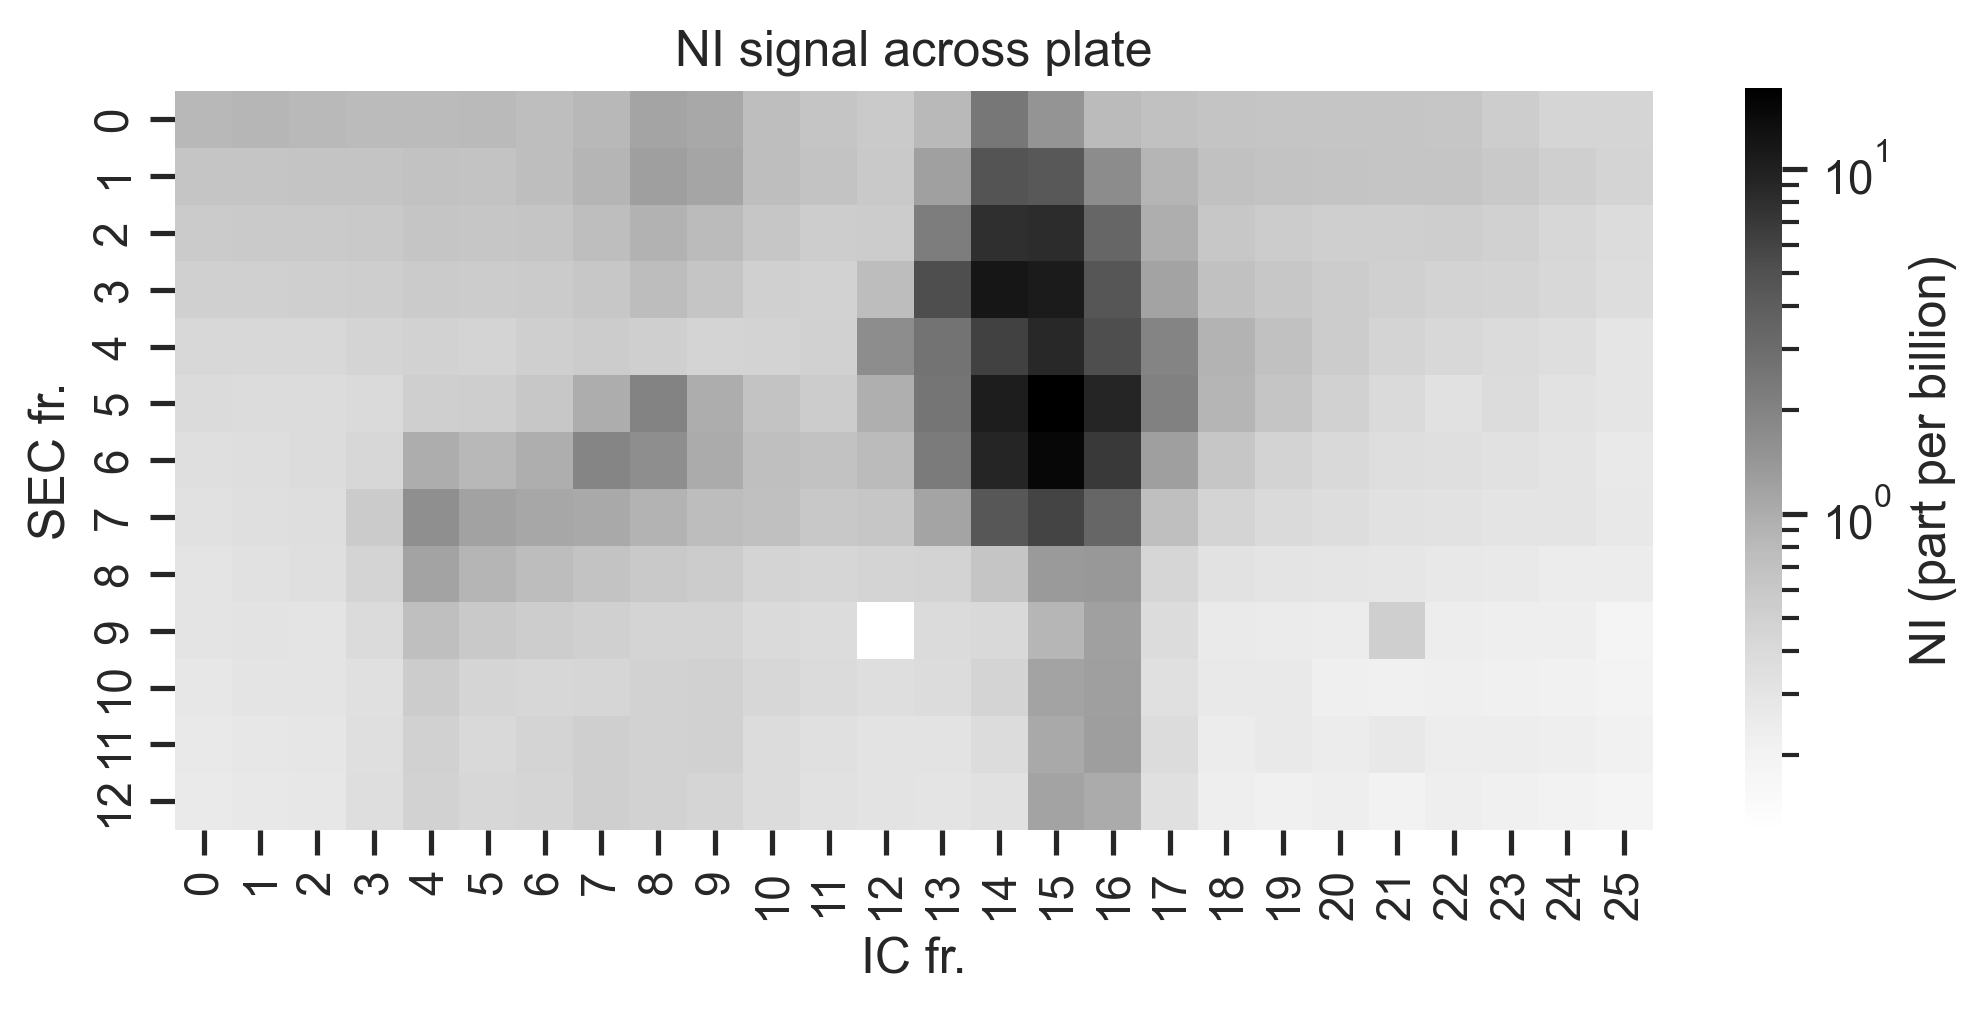

In [8]:
metal = "60Ni"
metal_translated = isotope_element_mapping[metal]

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.heatmap(metal_join_df.pivot(values=metal, index="x", on="y", )[:, 1:], cmap="Grays", square=True, cbar=True,
            norm=LogNorm(), cbar_kws={'label': f'{metal_translated} (part per billion)', 'shrink': 0.6}, ax=ax)

ax.set_ylabel("SEC fr.")
ax.set_xlabel("IC fr.")
ax.set_title(f"{metal_translated} signal across plate")

plt.tight_layout()

plt.savefig(f"figures/Ni_plate.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"figures/Ni_plate.png", 
            format='png', bbox_inches='tight')

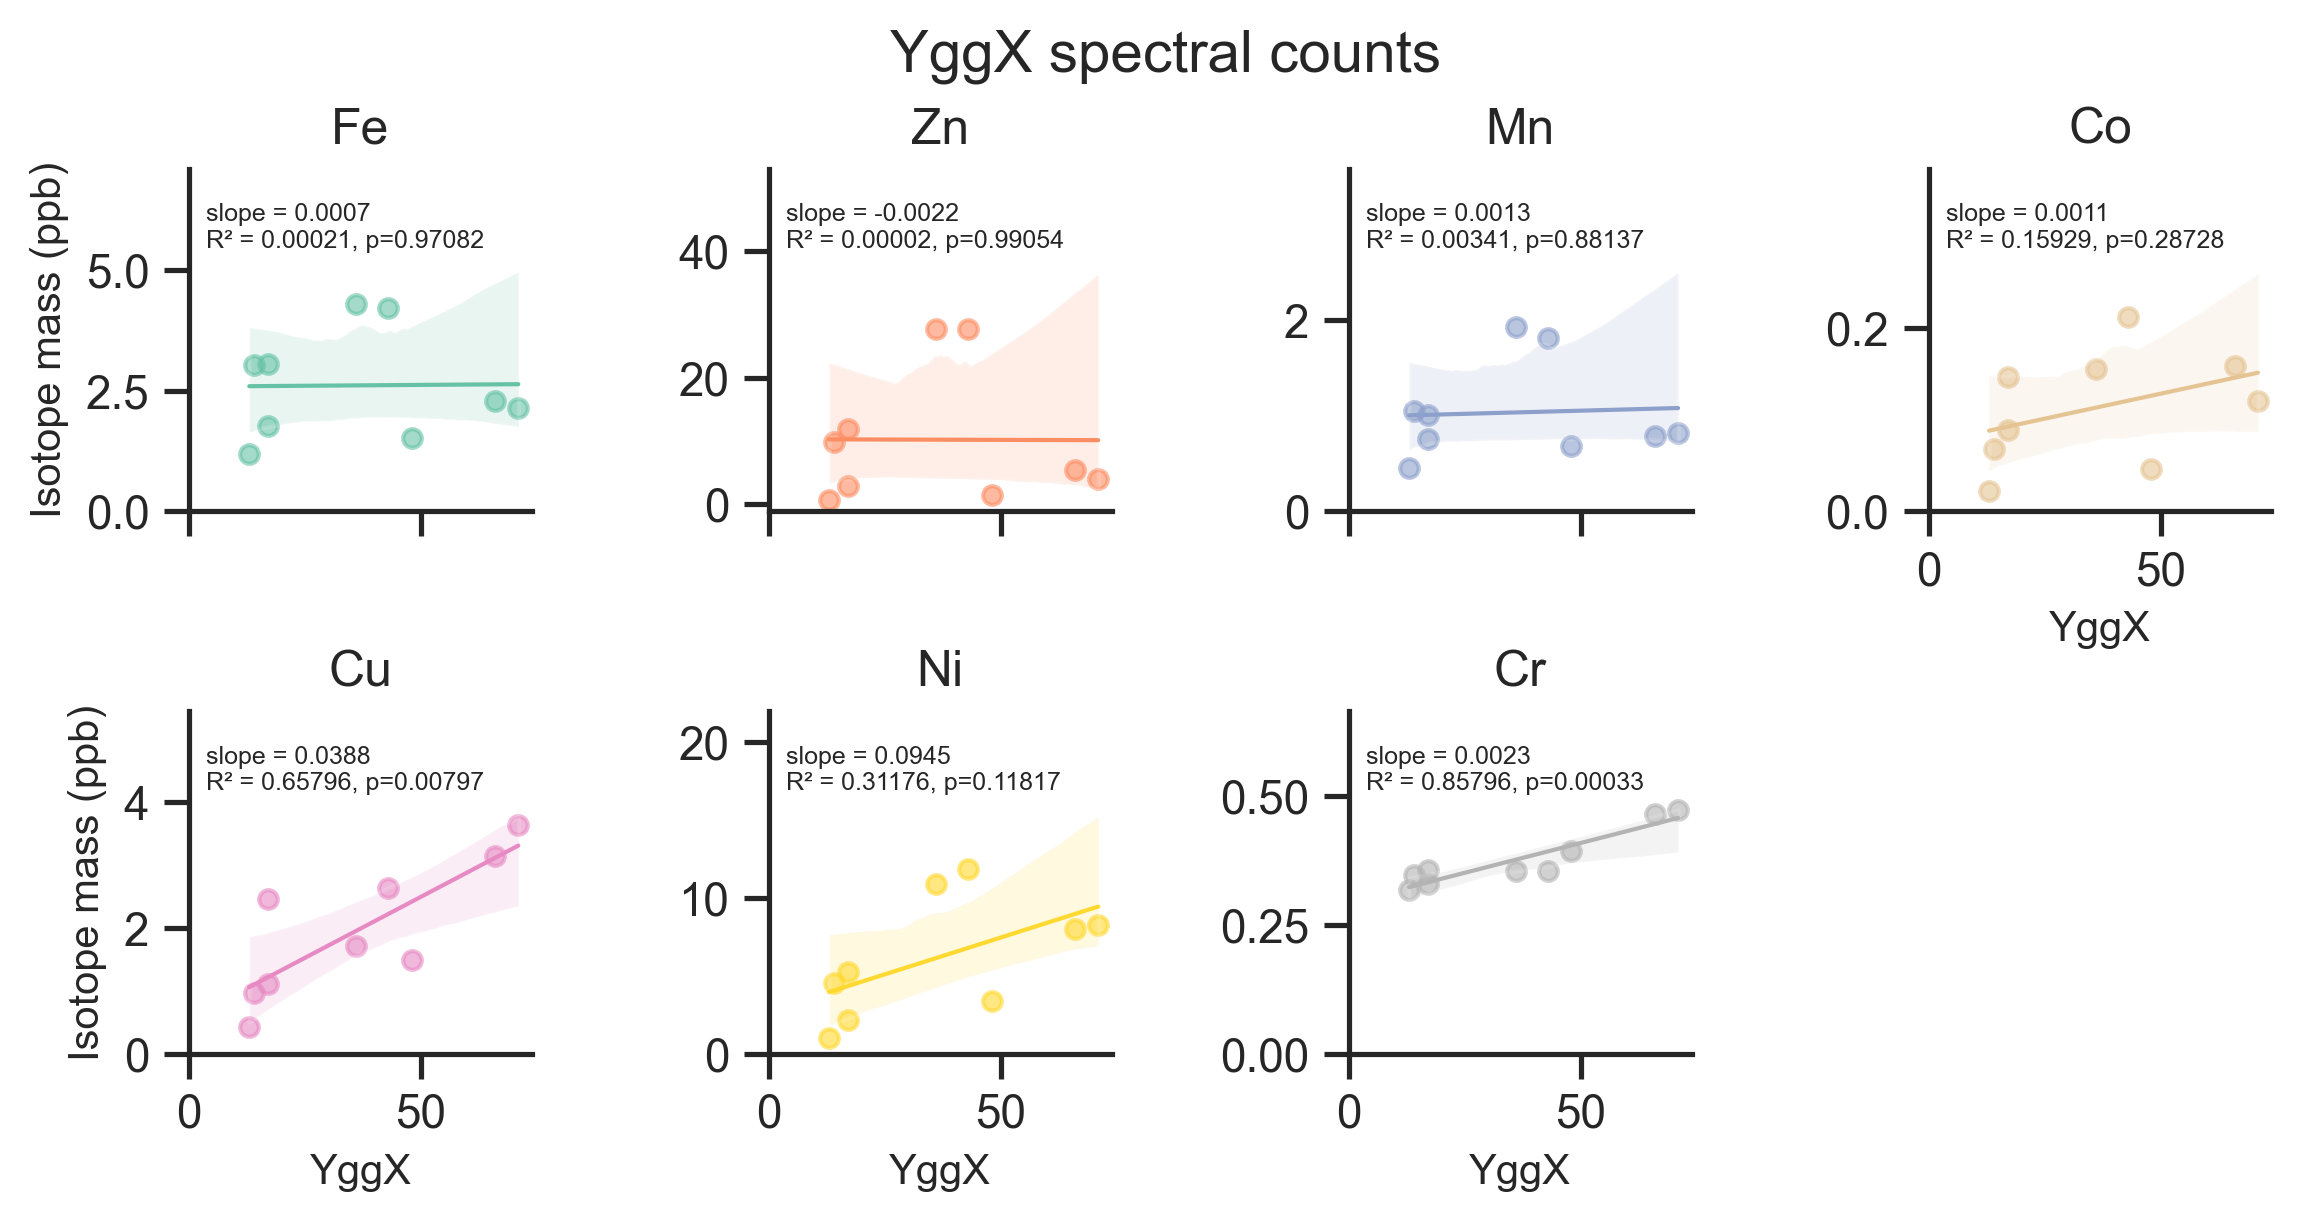

In [9]:
g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=YggX_subset, 
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4, 
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1, "linestyle": "-"},
               legend=False)

def annotate_fit_stats(data, **kws):
    x = data[gene].to_numpy(dtype=float)
    y = data["Isotope mass (ppb)"].to_numpy(dtype=float)
    fit = stats.linregress(x, y)
    slope, p, r2 = fit.slope, fit.pvalue, fit.rvalue ** 2
    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.4f}\nR² = {r2:.5f}, p={p:.5f}", 
            transform=ax.transAxes, fontsize=6, va="top")

g.map_dataframe(annotate_fit_stats)

g.set_axis_labels(gene, "Isotope mass (ppb)", fontsize=10)
g.set_titles("{col_name}", fontsize=12)
g.fig.suptitle(f'{gene} spectral counts', fontsize=14, y=1.02)

for _ax in g.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    
    # top headroom for stats text
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  

plt.savefig(f"figures/{gene}_isotope_correlations.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"figures/{gene}_isotope_correlations.png", 
            format='png', bbox_inches='tight')


# normalized values 

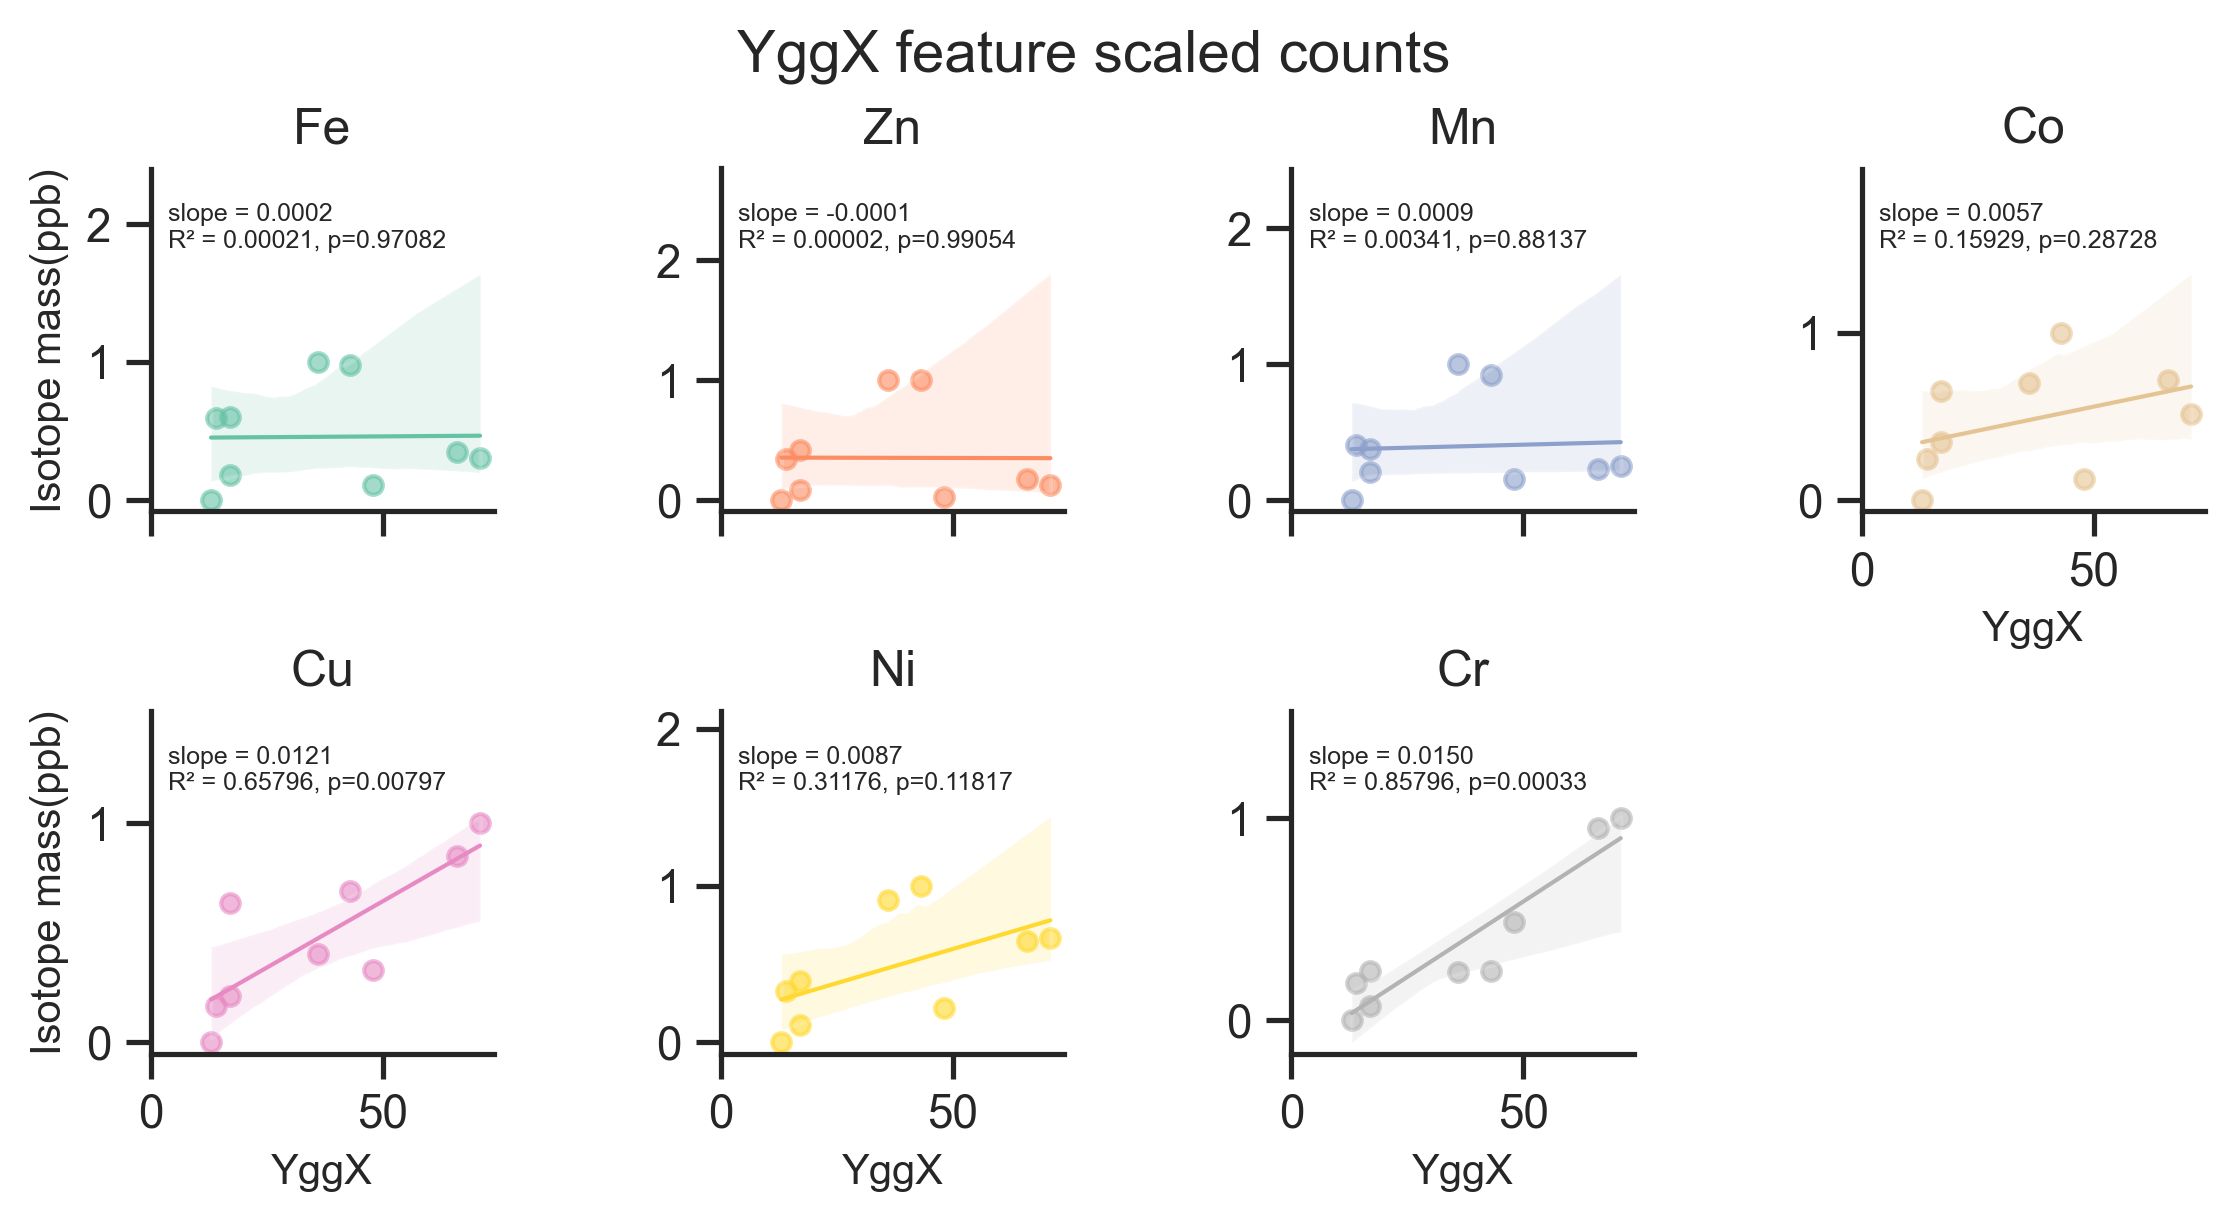

In [10]:
YggX_subset_norm = YggX_subset.with_columns(
    ((pl.col("Isotope mass (ppb)") - pl.col("Isotope mass (ppb)").min().over("Element")) /
     (pl.col("Isotope mass (ppb)").max().over("Element") - pl.col("Isotope mass (ppb)").min().over("Element"))
    ).alias("Isotope mass(ppb)")
)

g_norm = sns.lmplot(x=gene, y="Isotope mass(ppb)", hue="Element", data=YggX_subset_norm, 
                    height=2.0, aspect=1,
                    col="Element", col_order=element_order, col_wrap=4, 
                    sharey=False, palette=element_palette,
                    scatter_kws={"alpha": 0.6, "s": 20},
                    line_kws={"linewidth": 1, "linestyle": "-"},
                    legend=False)

def annotate_fit_stats_norm(data, **kws):
    x = data[gene].to_numpy(dtype=float)
    y = data["Isotope mass(ppb)"].to_numpy(dtype=float)
    fit = stats.linregress(x, y)
    slope, p, r2 = fit.slope, fit.pvalue, fit.rvalue ** 2
    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.4f}\nR² = {r2:.5f}, p={p:.5f}", 
            transform=ax.transAxes, fontsize=6, va="top")

g_norm.map_dataframe(annotate_fit_stats_norm)

g_norm.set_axis_labels(gene, "Isotope mass(ppb)", fontsize=10)
g_norm.set_titles("{col_name}", fontsize=12)
g_norm.fig.suptitle(f'{gene} feature scaled counts', fontsize=14, y=1.02)

for _ax in g_norm.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  
    
plt.savefig(f"figures/{gene}_isotope_correlations_scaled.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"figures/{gene}_isotope_correlations_scaled.png", 
            format='png', bbox_inches='tight')


# Avg signal (Zn, Fe, Mn) linear regression — all metals

In [11]:
all_elements = ["Fe", "Zn", "Mn", "Cu", "Ni", "Co", "Cr"]

pivot_norm_all = (
    YggX_subset_norm
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

pivot_norm_all = pivot_norm_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn") + pl.col("Cu") + pl.col("Ni") + pl.col("Co") + pl.col("Cr")) / 7)
)

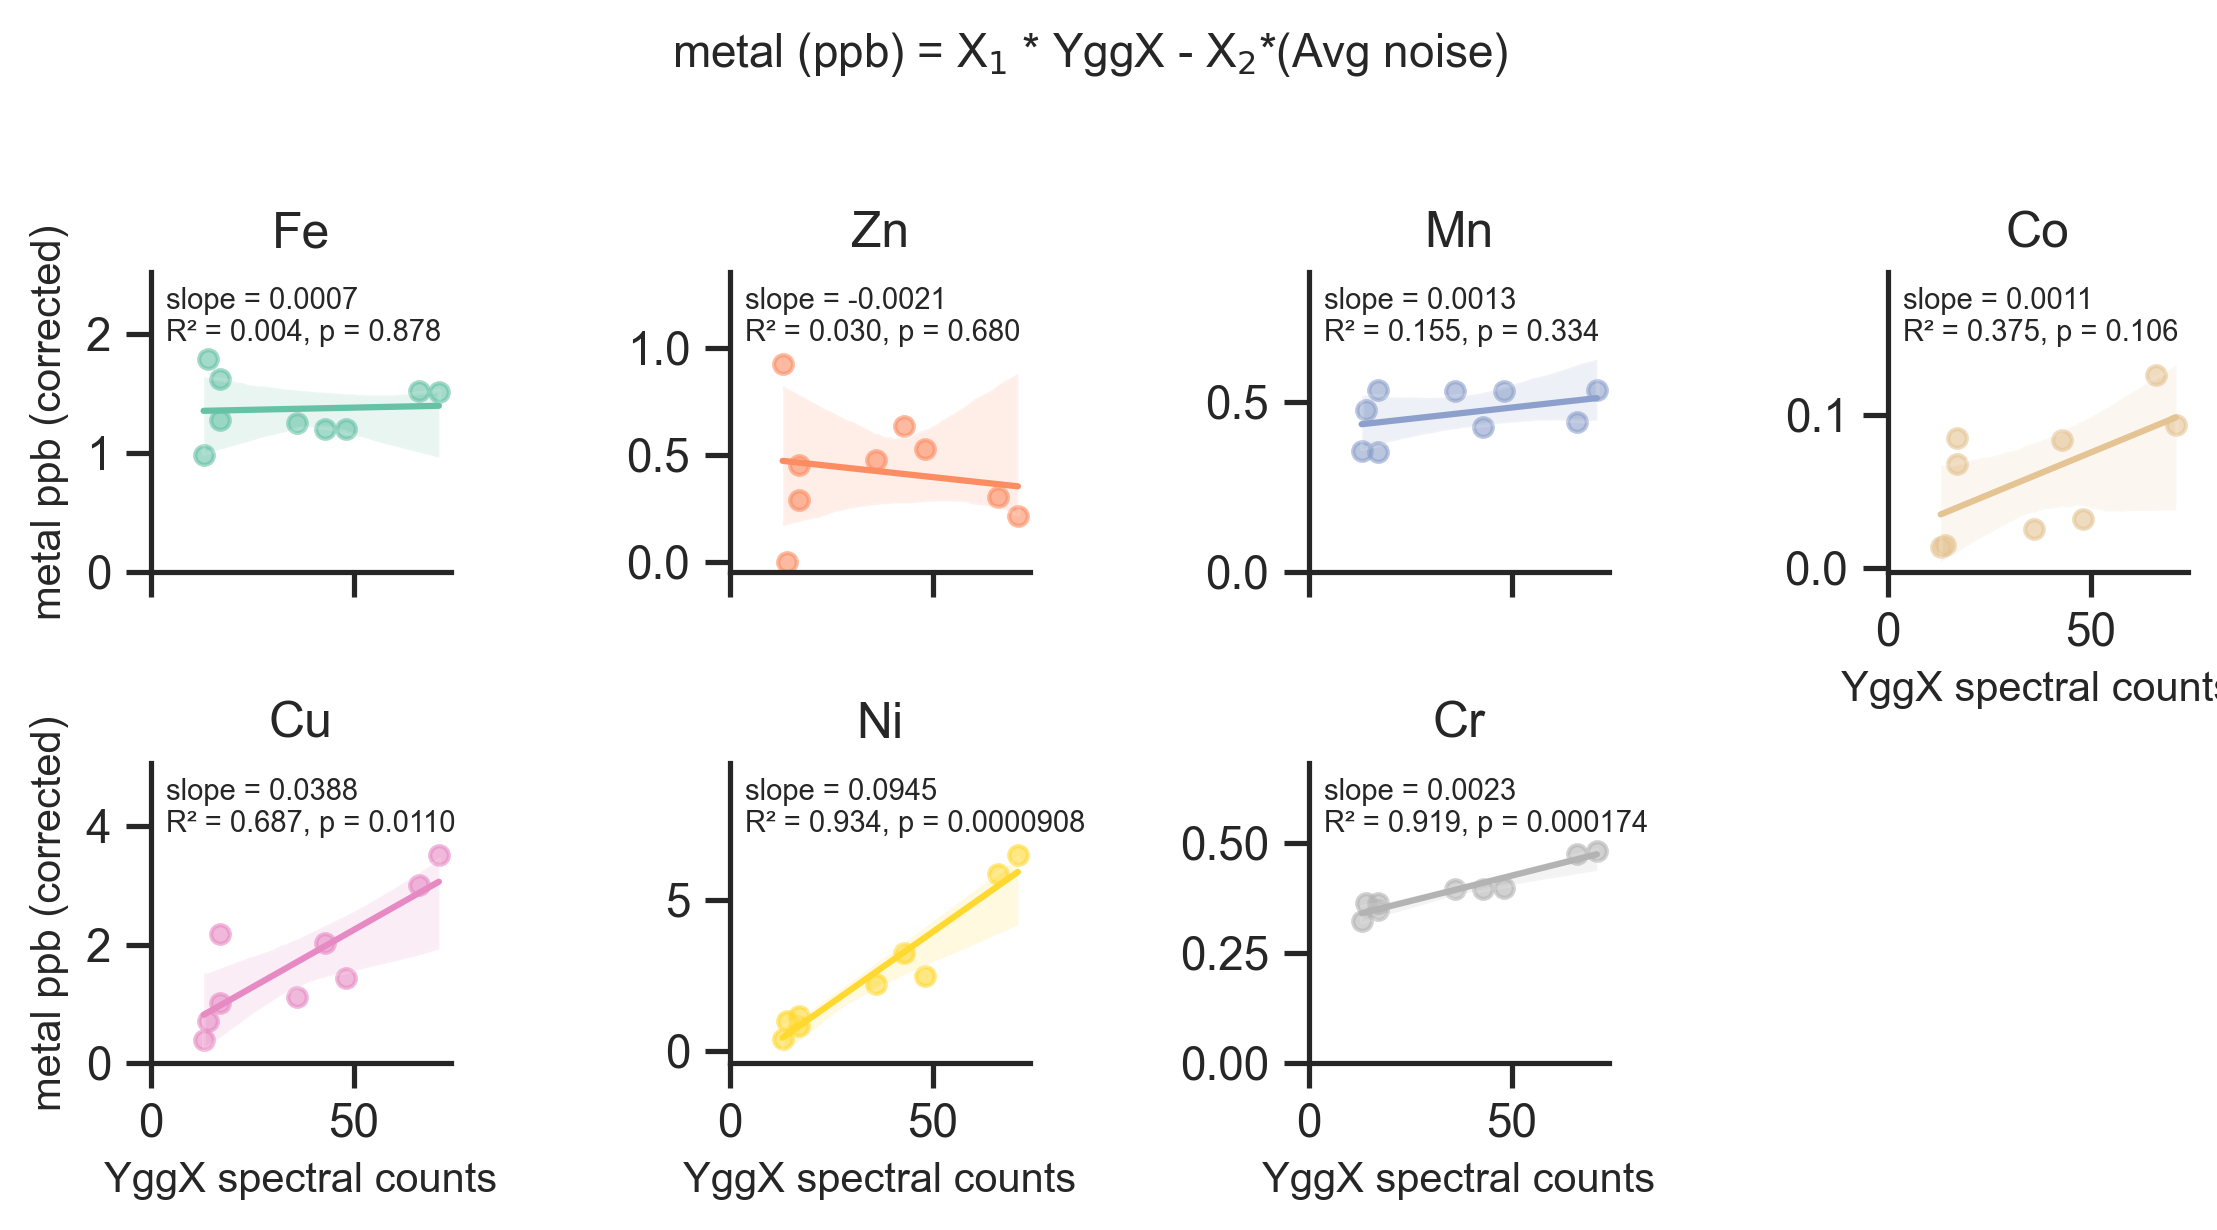

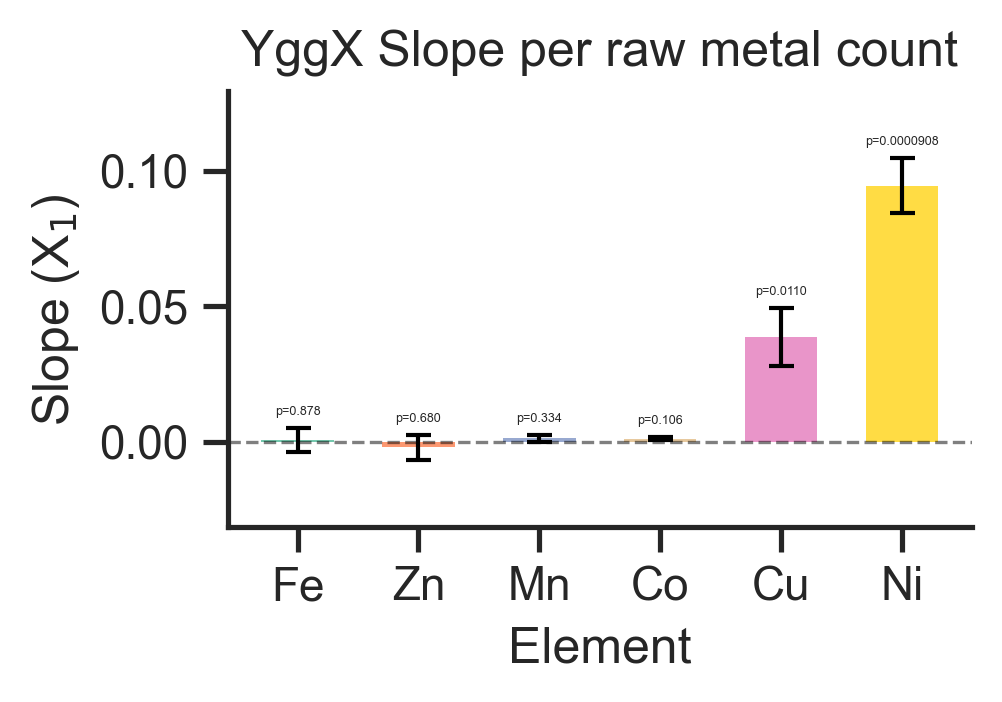

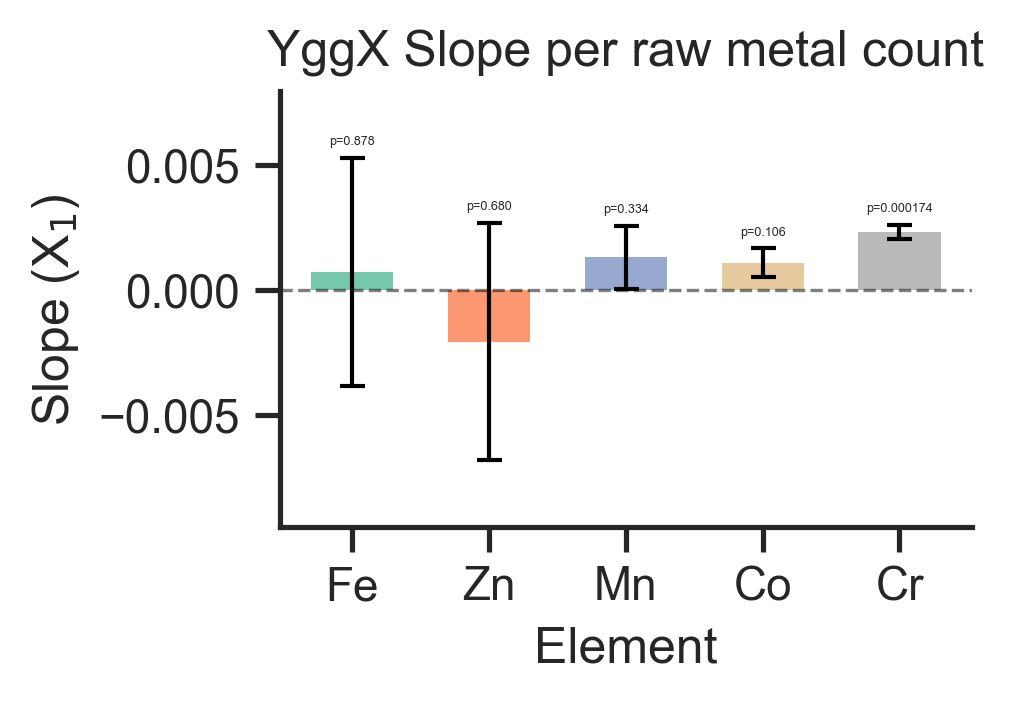

In [12]:
pivot_raw_all = (
    YggX_subset
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass (ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

BACKGROUND = ("Zn", "Fe", "Mn")

pivot_raw_all = pivot_raw_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn")) / 3)
)

plot_data_list_raw = []
slopes_raw = []
slope_ses_raw = []
stats_dict_raw = {}

for elem in element_order:
    df_pd = pivot_raw_all.select([gene, "avg_signal", elem]).to_pandas()
    df_pd.columns = ["YggX", "avg_signal", "metal"]

    X = df_pd[["YggX", "avg_signal"]].values
    y = df_pd["metal"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    X1, X2 = model.coef_

    n, p = X.shape
    residuals = y - y_pred
    MSE = np.sum(residuals ** 2) / (n - p - 1)
    X_aug = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    SE_X1 = np.sqrt(MSE * XtX_inv[1, 1])
    p_partial = 2 * stats.t.sf(abs(X1 / SE_X1), df=n - p - 1)

    slopes_raw.append(X1)
    slope_ses_raw.append(SE_X1)

    metal_corrected = y - X2 * df_pd["avg_signal"].values
    
    metal_corrected = metal_corrected + max(-metal_corrected.min(), 0)
    
    _, _, r_c, _, _ = stats.linregress(df_pd["YggX"].values, metal_corrected)

    stats_dict_raw[elem] = {"X1": X1, "r2": r_c ** 2, "p": p_partial}

    plot_df = pd.DataFrame({
        "YggX": df_pd["YggX"],
        "metal_corrected": metal_corrected,
        "Element": elem
    })
    plot_data_list_raw.append(plot_df)

combined_plot_data_raw = pd.concat(plot_data_list_raw, ignore_index=True)

g_raw = sns.lmplot(x="YggX", y="metal_corrected", hue="Element", data=combined_plot_data_raw,
                   height=2.0, aspect=1,
                   col="Element", col_order=element_order, col_wrap=4,
                   sharey=False, palette=element_palette,
                   scatter_kws={"alpha": 0.6, "s": 20},
                   line_kws={"linewidth": 1.5, "linestyle": "-"},
                   legend=False)

def annotate_stats_raw(data, **kws):
    ax = plt.gca()
    elem = data["Element"].iloc[0]
    stats_info = stats_dict_raw[elem]
    ax.text(0.05, 0.95,
            f"slope = {stats_info['X1']:.4f}\nR² = {stats_info['r2']:.3f}, p = {_p_plain(stats_info['p'])}",
            transform=ax.transAxes, fontsize=7, va="top")

g_raw.map_dataframe(annotate_stats_raw)

g_raw.set_axis_labels("YggX spectral counts", "metal ppb (corrected)", fontsize=10)
g_raw.set_titles("{col_name}", fontsize=10)
g_raw.figure.suptitle("metal (ppb) = X$_1$ * YggX - X$_2$*(Avg noise)", fontsize=11, y=1.02)

sns.despine()
plt.tight_layout()
for _ax in g_raw.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  

plt.savefig(f"figures/{gene}_metal_lr_avgAll_signal_raw.svg",
            format="svg", bbox_inches="tight")
plt.savefig(f"figures/{gene}_metal_lr_avgAll_signal_raw.png",
            format="png", bbox_inches="tight")
plt.show()


#slope bar plots
slope_by_elem = dict(zip(element_order, slopes_raw))
se_by_elem = dict(zip(element_order, slope_ses_raw))

group1 = ["Fe", "Zn", "Mn", "Co", "Cu", "Ni"]
group2 = ["Fe", "Zn", "Mn", "Co", "Cr"]

FIG_DIR = "figures"


def _draw_slope_bars(ax, elems, title, pvals):
    x = np.arange(len(elems))
    slopes = [slope_by_elem[e] for e in elems]
    ses = [se_by_elem[e] for e in elems]
    colors = [element_palette[e] for e in elems]
    ax.bar(x, slopes, color=colors, width=0.6, alpha=0.9, edgecolor="none")
    ax.errorbar(x, slopes, yerr=ses, fmt="none", color="black", capsize=3, lw=1)
    _annotate_pstars(ax, x, slopes, ses, pvals)
    ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(elems)
    ax.set_xlabel("Element")
    ax.set_ylabel("Slope (X$_1$)")
    ax.set_title(title)
    sns.despine(ax=ax)


for grp, tag, subtitle in [
    (group1, "group1", "Fe, Zn, Mn, Co, Cu, Ni"),
    (group2, "group2", "Fe, Zn, Mn, Co, Cr"),
]:
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    _draw_slope_bars(ax, grp, f"{gene} Slope per raw metal count",
                     [stats_dict_raw[e]["p"] for e in grp])
    if tag == "group2":
        _fmt = mticker.ScalarFormatter(useOffset=False)
        _fmt.set_scientific(False)
        ax.yaxis.set_major_formatter(_fmt)
    plt.tight_layout()
    for ext in ("svg", "png"):
        plt.savefig(f"{FIG_DIR}/{gene}_metal_slopes_barplot_raw_{tag}.{ext}",
                    format=ext, bbox_inches="tight")
    plt.show()


# yggX homolog expression across pathogens (GSE152295)

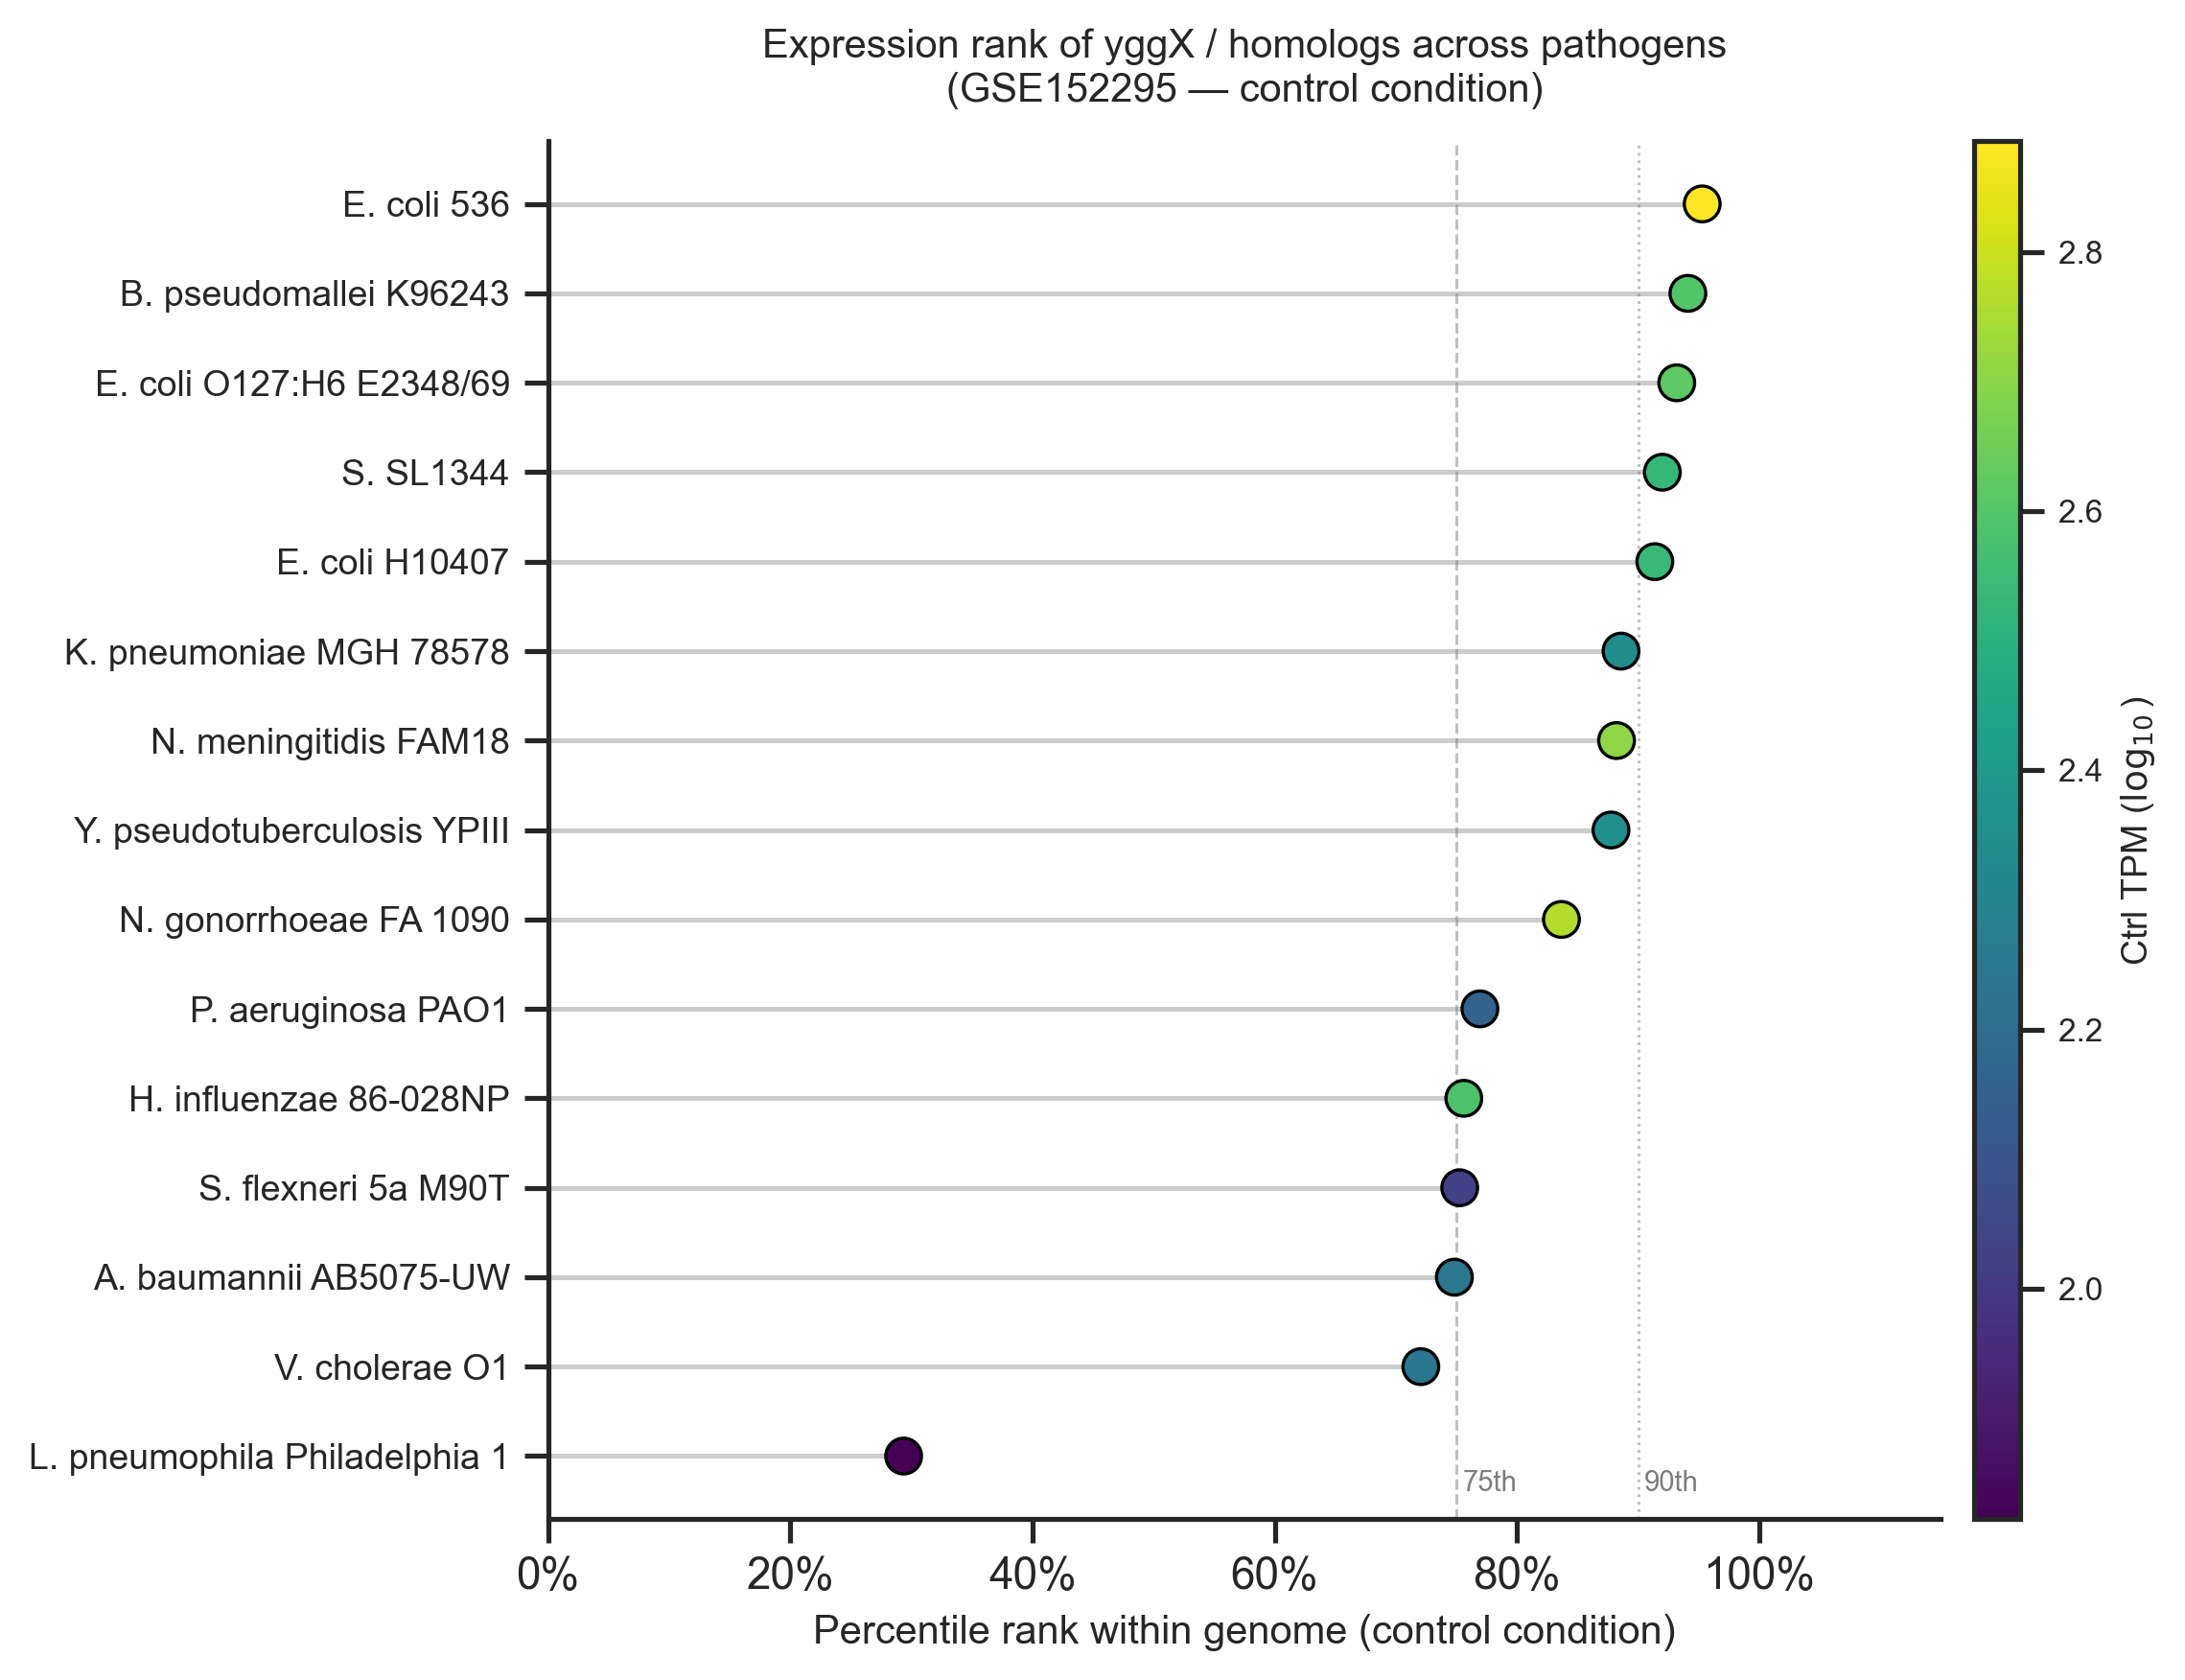

In [13]:
# --- yggX / homolog expression rank across GSE152295 pathogens (control condition) ---

_OUT = "figures"
Path(_OUT).mkdir(parents=True, exist_ok=True)

_YGGX     = Path("yggX_homologs")
_GEO_DIR  = _YGGX / "data" / "gse152295"
_HITS_CSV = _YGGX / "output" / "yggX_expression.csv"

_hits = pd.read_csv(_HITS_CSV)
_hits = _hits[_hits["found"] == True].copy()
_SKIP = {"subsp.", "enterica", "serovar", "str.", "strain"}


def _short_label(name):
    parts = name.split()
    keep = [w for w in parts[1:] if w.lower() not in _SKIP]
    return f"{parts[0][0]}. {' '.join(keep)}"


_records = []
for _, h in _hits.iterrows():
    with gzip.open(_GEO_DIR / f"GSE152295_{h['code']}_processed.txt.gz", "rt") as f:
        _df = pd.read_csv(f, sep="\t")
    ctrl_cols = [c for c in _df.columns if "_Ctrl_" in c and c.endswith("TPM")]
    _df["ctrl_mean"] = _df[ctrl_cols].mean(axis=1)
    _df = _df.sort_values("ctrl_mean", ascending=False).reset_index(drop=True)
    n_genes = len(_df)
    rank = int(_df[_df["Name"] == h["locus"]].index[0]) + 1  # 1-based
    _records.append({
        "label": _short_label(h["name"]),
        "locus": h["locus"],
        "pct": round(100.0 * (1 - rank / n_genes), 2),
        "ctrl_tpm": round(float(_df.loc[rank - 1, "ctrl_mean"]), 1),
    })

_rank_df = pd.DataFrame(_records).sort_values("pct").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

for i, row in _rank_df.iterrows():
    ax.hlines(y=i, xmin=0, xmax=row["pct"], color="#cccccc", linewidth=1.2, zorder=1)

_log_tpm = np.log10(_rank_df["ctrl_tpm"])
_sc = ax.scatter(_rank_df["pct"], range(len(_rank_df)), c=_log_tpm, cmap="viridis",
                 s=80, zorder=4, edgecolors="black", linewidths=0.8)


_cbar = fig.colorbar(_sc, ax=ax, pad=0.02, aspect=30)
_cbar.set_label(r"Ctrl TPM ($\log_{10}$)", fontsize=9)
_cbar.ax.tick_params(labelsize=8)

ax.set_yticks(range(len(_rank_df)))
ax.set_yticklabels(_rank_df["label"], fontsize=9)
ax.set_xlabel("Percentile rank within genome (control condition)", fontsize=10)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# 75th / 90th percentile guides -- same style as the panels above
ax.axvline(75, color="gray", lw=0.7, linestyle="--", alpha=0.5)
ax.axvline(90, color="gray", lw=0.7, linestyle=":", alpha=0.5)
ax.text(75.5, 0.02, "75th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(90.5, 0.02, "90th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())

ax.set_title("Expression rank of yggX / homologs across pathogens\n(GSE152295 — control condition)",
             fontsize=10, pad=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{_OUT}/yggX_rank_plot.svg", format="svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{_OUT}/yggX_rank_plot.png", format="png", dpi=150, bbox_inches="tight")
plt.show()

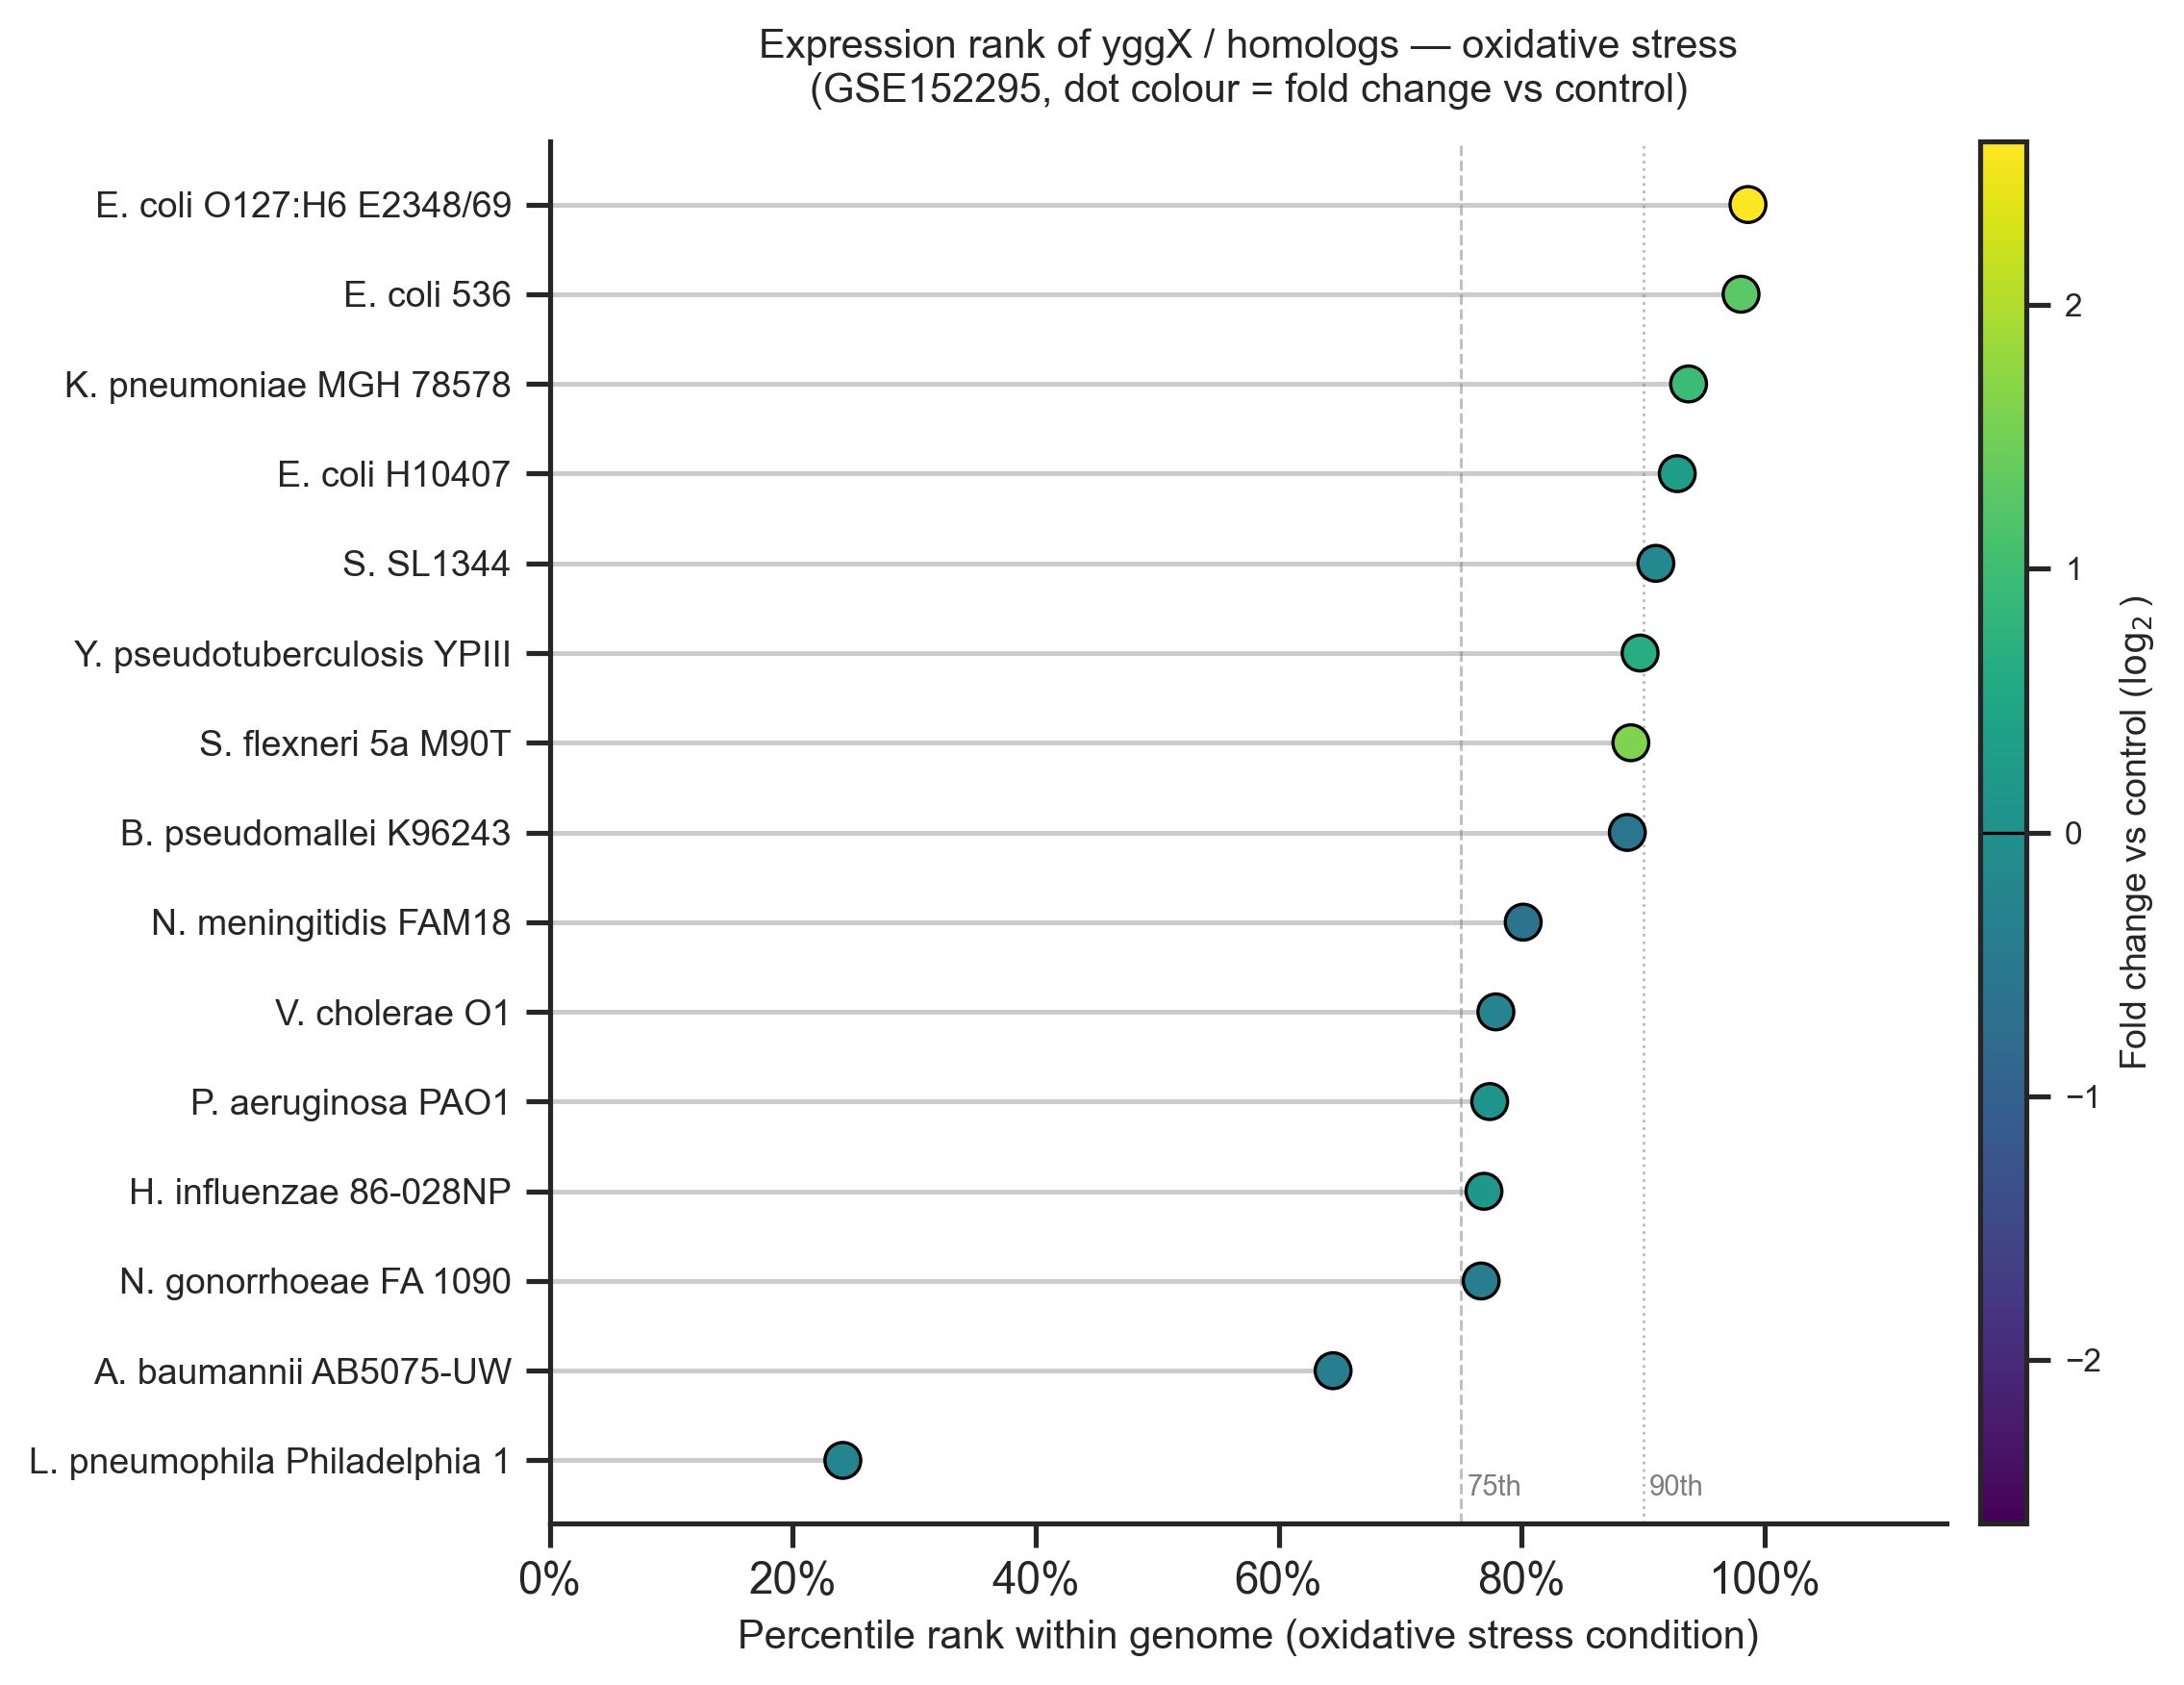

In [14]:
# --- yggX / homolog rank under oxidative stress; dot colour = log2 fold-change vs control ---

_records_ox = []
for _, h in _hits.iterrows():
    with gzip.open(_GEO_DIR / f"GSE152295_{h['code']}_processed.txt.gz", "rt") as f:
        _df = pd.read_csv(f, sep="\t")
    oxs_cols = [c for c in _df.columns if "_Oxs_" in c and c.endswith("TPM")]
    if not oxs_cols:
        continue  # skip species lacking an oxidative-stress condition
    _df["oxs_mean"] = _df[oxs_cols].mean(axis=1)
    _df = _df.sort_values("oxs_mean", ascending=False).reset_index(drop=True)
    n_genes = len(_df)
    rank = int(_df[_df["Name"] == h["locus"]].index[0]) + 1
    fc = float(h["Oxs_fc"]) if "Oxs_fc" in h else np.nan
    _records_ox.append({
        "label": _short_label(h["name"]),
        "locus": h["locus"],
        "pct": round(100.0 * (1 - rank / n_genes), 2),
        "log2fc": round(np.log2(fc), 3) if fc > 0 else np.nan,
    })

_ox_df = pd.DataFrame(_records_ox).sort_values("pct").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

for i, row in _ox_df.iterrows():
    ax.hlines(y=i, xmin=0, xmax=row["pct"], color="#cccccc", linewidth=1.2, zorder=1)

_fc_vals = _ox_df["log2fc"]
_abs_max = max(abs(_fc_vals.min()), abs(_fc_vals.max()), 0.5)
_norm = mcolors.TwoSlopeNorm(vmin=-_abs_max, vcenter=0, vmax=_abs_max)
_sc = ax.scatter(_ox_df["pct"], range(len(_ox_df)), c=_fc_vals, cmap="viridis", norm=_norm,
                 s=80, zorder=4, edgecolors="black", linewidths=0.8)


_cbar = fig.colorbar(_sc, ax=ax, pad=0.02, aspect=30)
_cbar.set_label(r"Fold change vs control ($\log_2$)", fontsize=9)
_cbar.ax.tick_params(labelsize=8)
_cbar.ax.axhline(y=0, color="black", linewidth=0.8)

ax.set_yticks(range(len(_ox_df)))
ax.set_yticklabels(_ox_df["label"], fontsize=9)
ax.set_xlabel("Percentile rank within genome (oxidative stress condition)", fontsize=10)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

ax.axvline(75, color="gray", lw=0.7, linestyle="--", alpha=0.5)
ax.axvline(90, color="gray", lw=0.7, linestyle=":", alpha=0.5)
ax.text(75.5, 0.02, "75th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(90.5, 0.02, "90th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())

ax.set_title("Expression rank of yggX / homologs — oxidative stress\n(GSE152295, dot colour = fold change vs control)",
             fontsize=10, pad=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{_OUT}/yggX_oxidative_plot.svg", format="svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{_OUT}/yggX_oxidative_plot.png", format="png", dpi=150, bbox_inches="tight")
plt.show()